In [5]:
"""Training loop for the Four-Room environment using GPI-PD.

GPI-PD (Generalized Policy Improvement with Prioritized Dynamics) is a
sample-efficient multi-objective RL algorithm that combines:
  - GPI  : at evaluation time, the agent picks the best action across all
            previously-learned weight-specific Q-functions.
  - PER  : prioritized experience replay to focus learning on surprising
            transitions.
  - Dyna : a learned probabilistic ensemble dynamics model that generates
            synthetic rollouts, greatly improving sample efficiency.

The four-room environment has a 4-dimensional reward vector:
  [blue_triangle, blue_circle, red_triangle, red_circle]
All rewards are +1 when the corresponding shape is collected, 0 otherwise.
"""

import sys
import os
import wandb

# ---------------------------------------------------------------------------
# Make sure the repo root is on the Python path so that the local `env`,
# `utils`, and `wrappers` packages can be imported regardless of where the
# script is launched from.
# ---------------------------------------------------------------------------
import gymnasium as gym
import numpy as np

import env  # noqa: F401  – registers "my-four-room-v0" as a side-effect
from morl_baselines.multi_policy.gpi_pd.gpi_pd import GPIPD
from utils.eval import eval_full_room_gpipd
from wrappers.combine_wrapper import CombineWrapper

# ---------------------------------------------------------------------------
# Hyperparameters – explained
# ---------------------------------------------------------------------------

# ── Training budget ─────────────────────────────────────────────────────────
TOTAL_TIMESTEPS = int(3e4)
# 100 000 environment steps is enough to see meaningful convergence on this
# small (5×5) grid while keeping wall-clock time reasonable (a few minutes
# on CPU).

# ── Episode length cap ───────────────────────────────────────────────────────
MAX_EPISODE_LENGTH = 8
# Without a cap the agent could wander indefinitely on episodes where the goal
# is never reached.  50 steps is ≈10× the Manhattan diameter of the grid, so
# any optimal or near-optimal policy will finish well within this budget.

# ── GPI-PD / Q-learning ─────────────────────────────────────────────────────
LEARNING_RATE = 3e-4
# Standard Adam learning rate; works well across a broad class of deep-RL
# problems.

GAMMA = 0.99
# Discount factor.  0.99 lets the agent plan several steps ahead, important
# for collecting shapes that may be far from the starting cell.

BATCH_SIZE = 256
# Larger batches than the default (128) help on this environment because the
# effective state space is small and the replay buffer fills quickly with
# redundant transitions; bigger batches reduce variance with little extra cost.

BUFFER_SIZE = int(5e4)
# 50 000 transitions is more than enough for a 5×5 grid; keeping it modest
# avoids the first few thousand steps being dominated by near-zero-priority
# samples from before the policy has learned anything useful.

GRADIENT_UPDATES = 10
# Number of gradient steps taken per environment step once learning starts.
# The default (20) is appropriate for harder environments; 10 is sufficient
# here and halves training time.

LEARNING_STARTS = 250
# Collect 500 random transitions before the first gradient update so that the
# replay buffer already contains some diversity.

NET_ARCH = [64, 64]
# Two hidden layers of 64 units each.  The observation is only 2+8 = 10
# dimensional (position + collected-shape binary vector), so a smaller
# network than the default (4×256) converges faster and is less prone to
# overfitting.

TARGET_NET_UPDATE_FREQ = 250
# Hard-copy the online Q-network to the target network every 500 steps.
# This stabilises training while still providing reasonably fresh targets.

# ── Exploration ──────────────────────────────────────────────────────────────
INITIAL_EPSILON = 0.3
# Start with 30 % random exploration so the agent visits different rooms
# before the policy solidifies.

FINAL_EPSILON = 0.05
# Keep 5 % random exploration throughout training to avoid getting stuck in
# local optima (the grid has multiple shapes, so greedy behaviour can miss
# entire rooms).

EPSILON_DECAY_STEPS = TOTAL_TIMESTEPS // 2
# Linearly anneal epsilon over the first half of training.

# ── Dyna (model-based rollouts) ───────────────────────────────────────────────
DYNA = False
# Enable the learned dynamics model; it is the primary source of sample
# efficiency in GPI-PD.

DYNAMICS_ROLLOUT_STARTS = 2000
# Wait until 2 000 real transitions have been collected before starting model
# rollouts so that the ensemble has enough data to produce useful predictions.

DYNAMICS_ROLLOUT_FREQ = 250
# Generate new synthetic transitions every 250 environment steps.

DYNAMICS_ROLLOUT_LEN = 1
# One-step rollouts are sufficient for this simple environment and avoid
# compounding model errors over long imagined trajectories.

DYNAMICS_ROLLOUT_BATCH_SIZE = 10000
# Number of synthetic transitions to generate per rollout phase.  Together
# with a real_ratio of 0.5, half of every training batch will be synthetic,
# which roughly doubles the effective sample size.

DYNAMICS_NET_ARCH = [64, 64, 64]
# Smaller ensemble network than the default (3×256) because the transition
# dynamics of the four-room grid are deterministic and low-dimensional.

DYNAMICS_ENSEMBLE_SIZE = 5
# Five ensemble members provide good uncertainty estimates while staying fast.

DYNAMICS_NUM_ELITES = 2
# Use the two best ensemble members for rollouts (standard practice).

REAL_RATIO = 0.5
# 50 % real / 50 % synthetic transitions in each training batch.

# ── Prioritized Experience Replay (PER) ─────────────────────────────────────
PER = True
# Enable PER so that surprising (high-TD-error) transitions are replayed more
# often.  Particularly useful in sparse-reward settings like this one where
# most transitions carry zero reward.

ALPHA_PER = 0.6
# PER exponent: 0 = uniform sampling, 1 = fully prioritised.
# 0.6 is the canonical value from the original PER paper.

# ── Multi-objective / GPI ────────────────────────────────────────────────────
USE_GPI = True
# Enable Generalised Policy Improvement so the agent can leverage all
# previously learned weight-specific Q-functions at decision time.

GPI_PD = True
# Enable the GPI-PD priority update, which re-scores transitions according to
# the GPI improvement signal rather than per-policy TD error alone.

# ── Training / evaluation schedule ──────────────────────────────────────────
TIMESTEPS_PER_ITER = TOTAL_TIMESTEPS // 10 # TODO: adjust
# Each outer iteration trains for 10 000 steps then picks a new weight vector.
# With TOTAL_TIMESTEPS = 1e5 this gives 10 outer iterations.

EVAL_FREQ = 2000
# Evaluate the current policy every 2 000 steps (logged to W&B).

EVAL_MO_FREQ = 10000
# Run the full multi-objective evaluation (hypervolume, EUM, etc.) every
# 10 000 steps – once per outer iteration.

NUM_EVAL_WEIGHTS_FOR_FRONT = 25
# Sample 100 uniformly-spaced weight vectors to approximate the Pareto front
# at evaluation time.

NUM_EVAL_EPISODES_FOR_FRONT = 5
# Run 5 episodes per weight vector during evaluation.  This is enough to
# average out stochastic starting positions in the four-room grid.

# ── Reference point (hypervolume lower bound) ────────────────────────────────
REF_POINT = np.array([0.0, 0.0])

# ── Logging ──────────────────────────────────────────────────────────────────
LOG = True

EXPERIMENT_NAME = "GPI-PD"
PROJECT_NAME = "MORL-Baselines"
SEED = 42

In [6]:
interp_weights = np.linspace(0, 1, 5)

for triangle_weight in interp_weights:
    circle_weight = 1 - triangle_weight
    interp_weight = np.array([triangle_weight, circle_weight])

    train_env = CombineWrapper(gym.wrappers.TimeLimit(
        gym.make("my-four-room-v0"),
        max_episode_steps=MAX_EPISODE_LENGTH,
    ), interp_weight)

    eval_env = CombineWrapper(gym.wrappers.TimeLimit(
        gym.make("my-four-room-v0"),
        max_episode_steps=MAX_EPISODE_LENGTH,
    ), interp_weight)

    # ---------------------------------------------------------------------------
    # Agent
    # ---------------------------------------------------------------------------
    agent = GPIPD(
        env=train_env,
        # Q-learning
        learning_rate=LEARNING_RATE,
        gamma=GAMMA,
        batch_size=BATCH_SIZE,
        buffer_size=BUFFER_SIZE,
        gradient_updates=GRADIENT_UPDATES,
        learning_starts=LEARNING_STARTS,
        net_arch=NET_ARCH,
        target_net_update_freq=TARGET_NET_UPDATE_FREQ,
        # Exploration
        initial_epsilon=INITIAL_EPSILON,
        final_epsilon=FINAL_EPSILON,
        epsilon_decay_steps=EPSILON_DECAY_STEPS,
        # Dyna
        dyna=DYNA,
        dynamics_rollout_starts=DYNAMICS_ROLLOUT_STARTS,
        dynamics_rollout_freq=DYNAMICS_ROLLOUT_FREQ,
        dynamics_rollout_len=DYNAMICS_ROLLOUT_LEN,
        dynamics_rollout_batch_size=DYNAMICS_ROLLOUT_BATCH_SIZE,
        dynamics_net_arch=DYNAMICS_NET_ARCH,
        dynamics_ensemble_size=DYNAMICS_ENSEMBLE_SIZE,
        dynamics_num_elites=DYNAMICS_NUM_ELITES,
        real_ratio=REAL_RATIO,
        # PER
        per=PER,
        alpha_per=ALPHA_PER,
        # Multi-objective / GPI
        use_gpi=USE_GPI,
        gpi_pd=GPI_PD,
        # Logging / misc
        log=LOG,
        experiment_name=EXPERIMENT_NAME + f"_weight_{interp_weight[0]:.2f}_{interp_weight[1]:.2f}",
        project_name=PROJECT_NAME,
        seed=SEED,
    )

    # wandb.log({"interp_weight": interp_weight })
    agent.close_wandb = lambda: None # prevent agent from closing W&B run at the end of training

    # ---------------------------------------------------------------------------
    # Training
    # ---------------------------------------------------------------------------
    agent.train(
        total_timesteps=TOTAL_TIMESTEPS,
        eval_env=eval_env,
        ref_point=REF_POINT,
        timesteps_per_iter=TIMESTEPS_PER_ITER,
        weight_selection_algo="gpi-ls",  # iteratively focus on under-explored
                                        # regions of the Pareto front
        eval_freq=EVAL_FREQ,
        eval_mo_freq=EVAL_MO_FREQ,
        num_eval_weights_for_front=NUM_EVAL_WEIGHTS_FOR_FRONT,
        num_eval_episodes_for_front=NUM_EVAL_EPISODES_FOR_FRONT,
        checkpoints=False,
    )

    agent.save(filename=f"gpipd_four_room_{interp_weight[0]}_{interp_weight[1]}_{wandb.run.id}")
    eval_full_room_gpipd(agent, n_weights=25, n_episodes_per_weight=5)

    train_env.close()
    eval_env.close()
    wandb.finish()

wandb: ERROR Unable to save notebook session history.


global_step,▁▁▁▁▁▁▁▁
global_step,0


CCS: [] CCS size: 0
Next weight: [1. 0.]
Next weight vector: [1. 0.]


: 

In [4]:
agent.save(filename="gpipd_four_room_triangle")

Collected points: 50
Non-dominated points: 3
Pareto front shape: (3, 2)


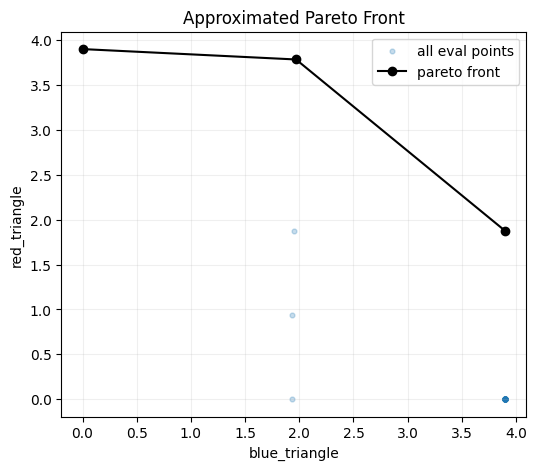

In [ ]:
# Approximate Pareto front from a trained GPIPD/GPILS agent
from morl_baselines.common.evaluation import policy_evaluation_mo
from morl_baselines.common.weights import equally_spaced_weights
from morl_baselines.common.pareto import filter_pareto_dominated
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_WEIGHTS = 25
N_EPISODES_PER_WEIGHT = 5

# Evaluate the trained policy set for many preference weights
eval_weights = equally_spaced_weights(agent.reward_dim, n=N_WEIGHTS)
returns = np.array(
    [policy_evaluation_mo(agent, eval_env, w, rep=N_EPISODES_PER_WEIGHT)[3] for w in eval_weights],
    dtype=np.float32,
 )

# Keep only non-dominated points (Pareto front approximation)
pareto_front = np.array(list(filter_pareto_dominated(returns)), dtype=np.float32)

print(f"Collected points: {len(returns)}")
print(f"Non-dominated points: {len(pareto_front)}")
print("Pareto front shape:", pareto_front.shape)

# Sort for cleaner plotting in 2D
if pareto_front.shape[1] == 2:
    pareto_front = pareto_front[np.argsort(pareto_front[:, 0])]

# Plot
if pareto_front.shape[1] == 2:
    plt.figure(figsize=(6, 5))
    plt.scatter(returns[:, 0], returns[:, 1], s=12, alpha=0.25, label="all eval points")
    plt.plot(pareto_front[:, 0], pareto_front[:, 1], "o-", color="black", label="pareto front")
    plt.xlabel("blue_triangle")
    plt.ylabel("red_triangle")
    plt.title("Approximated Pareto Front")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
elif pareto_front.shape[1] == 3:
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pareto_front[:, 0], pareto_front[:, 1], pareto_front[:, 2], s=20)
    ax.set_xlabel("objective_1")
    ax.set_ylabel("objective_2")
    ax.set_zlabel("objective_3")
    ax.set_title("Approximated Pareto Front")
    plt.show()
else:
    print("Front has", pareto_front.shape[1], "objectives; skipping plot.")

# Optional: save to CSV
# front_df = pd.DataFrame(pareto_front, columns=[f"objective_{i+1}" for i in range(pareto_front.shape[1])])
# front_df.to_csv("run_code/gpipd_pareto_front.csv", index=False)
# front_df.head()

In [3]:
train_env = CombineWrapper(gym.wrappers.TimeLimit(
    gym.make("my-four-room-v0"),
    max_episode_steps=MAX_EPISODE_LENGTH,
), [1, 0])

eval_env = CombineWrapper(gym.wrappers.TimeLimit(
    gym.make("my-four-room-v0"),
    max_episode_steps=MAX_EPISODE_LENGTH,
), [1, 0])

agent = GPIPD(
    env=train_env,
    # Q-learning
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    batch_size=BATCH_SIZE,
    buffer_size=BUFFER_SIZE,
    gradient_updates=GRADIENT_UPDATES,
    learning_starts=LEARNING_STARTS,
    net_arch=NET_ARCH,
    target_net_update_freq=TARGET_NET_UPDATE_FREQ,
    # Exploration
    initial_epsilon=INITIAL_EPSILON,
    final_epsilon=FINAL_EPSILON,
    epsilon_decay_steps=EPSILON_DECAY_STEPS,
    # Dyna
    dyna=DYNA,
    dynamics_rollout_starts=DYNAMICS_ROLLOUT_STARTS,
    dynamics_rollout_freq=DYNAMICS_ROLLOUT_FREQ,
    dynamics_rollout_len=DYNAMICS_ROLLOUT_LEN,
    dynamics_rollout_batch_size=DYNAMICS_ROLLOUT_BATCH_SIZE,
    dynamics_net_arch=DYNAMICS_NET_ARCH,
    dynamics_ensemble_size=DYNAMICS_ENSEMBLE_SIZE,
    dynamics_num_elites=DYNAMICS_NUM_ELITES,
    real_ratio=REAL_RATIO,
    # PER
    per=PER,
    alpha_per=ALPHA_PER,
    # Multi-objective / GPI
    use_gpi=USE_GPI,
    gpi_pd=GPI_PD,
    # Logging / misc
    log=LOG,
    experiment_name=EXPERIMENT_NAME,
    project_name=PROJECT_NAME,
    seed=SEED,
)
# agent.load(path="weights/GPI-PD.tar")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kristofs (kristofs-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


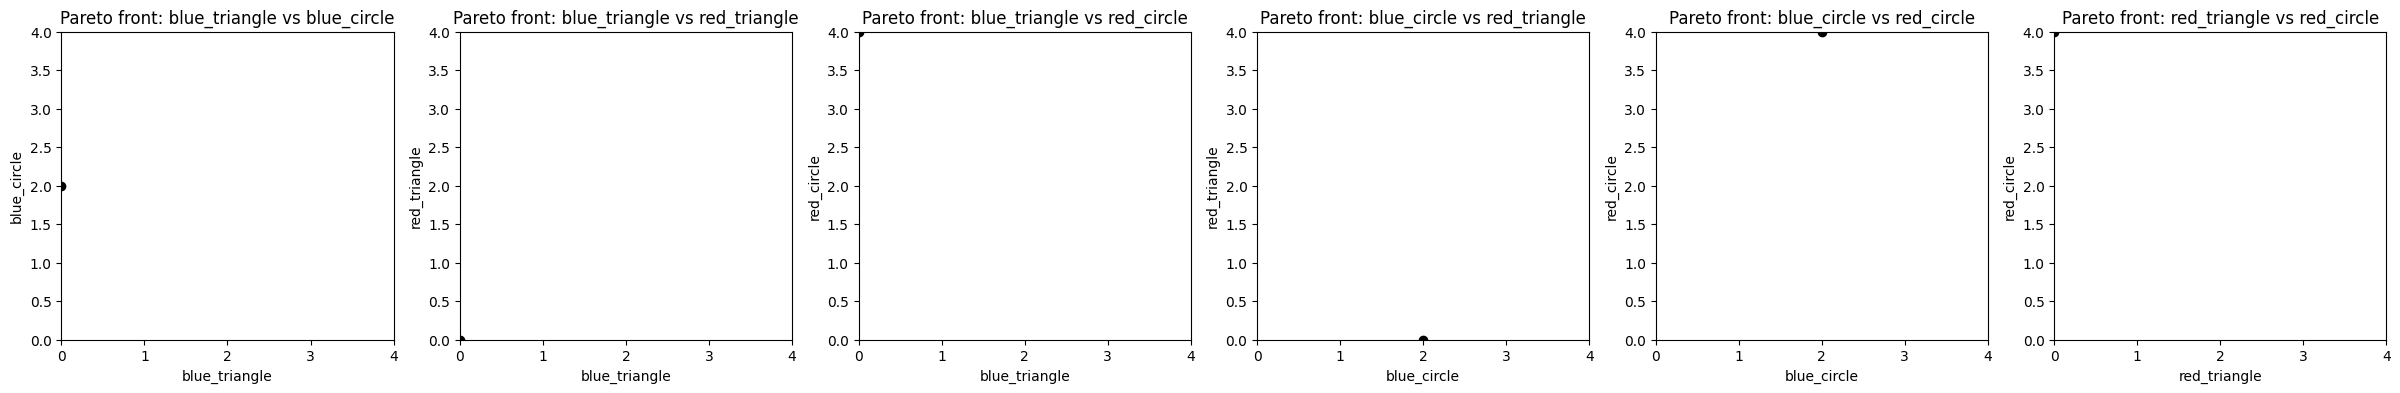

In [4]:
agent.load(path="weights/gpipd_four_room_0.0_1.0_kxr77lc4.tar")
eval_full_room_gpipd(agent, n_weights=25, n_episodes_per_weight=5)

In [3]:
gym.envs.registry["my-four-room-v0"]

EnvSpec(id='my-four-room-v0', entry_point='env.my_four_room:MyFourRoom', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='my-four-room', version=0, additional_wrappers=(), vector_entry_point=None)